In [ ]:
!pip install -q kaggle

In [ ]:
# enter your Kaggle credentionals here
import os
os.environ['KAGGLE_USERNAME']="vinay.198187@gmail.com"
os.environ['KAGGLE_API_TOKEN']="##################"

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -ltr /content/drive/MyDrive/

total 1069
-rw------- 1 root root 562616 Feb 25 19:19  analyze_visualize.html
-rw------- 1 root root 149988 Feb 25 19:22  Fetch_loadrawdata.html
-rw------- 1 root root  40441 Feb 25 19:22  normalize_load.html
-rw------- 1 root root 327769 Feb 25 19:55  notebook_html_files.zip
-rw------- 1 root root    177 Mar  2 14:52  analyze_visualize.gdoc
-rw------- 1 root root    177 Mar  2 14:54  normalize_load.gdoc
drwx------ 2 root root   4096 Apr  3 14:45 'Colab Notebooks'
drwx------ 2 root root   4096 Apr  3 20:56  my_models
drwx------ 2 root root   4096 Apr  8 14:19  chest-data


In [ ]:
ROOT_DIR = '/content/drive/MyDrive/chest-data'
if not os.path.exists(ROOT_DIR):
    os.makedirs(ROOT_DIR)
os.chdir(ROOT_DIR)

In [ ]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge

100% 3.66G/3.66G [00:55<00:00, 70.8MB/s]



In [ ]:
!unzip -q rsna-pneumonia-detection-challenge.zip

In [ ]:
!ls -ltr /content/drive/MyDrive/chest-data/stage_2_train_images/ | head

total 3478695
-rw------- 1 root root 147322 Dec 11  2019 02475a31-ed48-4ff3-b401-5d74694bff8d.dcm
-rw------- 1 root root 102110 Dec 11  2019 02363fdb-4cd0-4631-b3d8-7a10fddffa28.dcm
-rw------- 1 root root 150886 Dec 11  2019 023558cc-fcca-4fc2-9749-175e2727d49d.dcm
-rw------- 1 root root 142032 Dec 11  2019 02336c62-4e72-4818-8198-c327096a71e0.dcm
-rw------- 1 root root 107216 Dec 11  2019 0232c2b8-f7ac-4f42-84be-510ccb7cf351.dcm
-rw------- 1 root root 143098 Dec 11  2019 022b7bbd-963b-49ea-afd7-b6b7986da555.dcm
-rw------- 1 root root 153366 Dec 11  2019 02285fa4-35b7-4af6-b88f-3cac45a7f5c8.dcm
-rw------- 1 root root 153286 Dec 11  2019 02242633-faa0-4927-81de-b2b44940068a.dcm
-rw------- 1 root root 145498 Dec 11  2019 0216bae7-3ab6-4857-8cc1-3afe8dab3964.dcm


In [1]:
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.3 MB/s eta 0:00:0000:0100:01


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28330.1517874484.570928
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28330.1517874484.570928
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

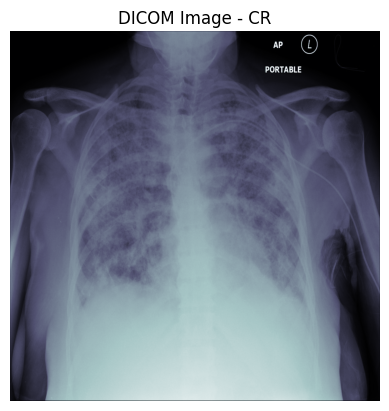

In [ ]:
import pydicom
from pydicom.data import get_testdata_files
import matplotlib.pyplot as plt

# 1. Load the DICOM file
# Replace 'path/to/your/image.dcm' with your actual file path
filename = "/content/drive/MyDrive/chest-data/stage_2_train_images/01d4fa0f-97a0-4522-b0d8-134400db2a3e.dcm"

ds = pydicom.dcmread(filename)
print(ds)

# 2. View Metadata (Properties)
print(f"Patient Name: {ds.PatientName}")
print(f"Modality: {ds.Modality}")
# print(f"Study Description: {ds.StudyDescription}")
# Print all metadata
# print(ds)

# 3. View the Image
plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
plt.title(f"DICOM Image - {ds.Modality}")
plt.axis('off')
plt.show()
